# Milk Yield Prediction Pipeline
**Dataset:** CowNflow (414 Holstein dairy cow records, INRAE)  
**Target:** Daily milk yield (kg/day)  
**Strategy:** EDA → Feature Engineering → Baseline Models → Hyperparameter Tuning → Stacking Ensemble

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import clone
from scipy.stats import randint, uniform
from tqdm import tqdm
import threading, time

import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.15)
PAL = sns.color_palette("muted")

print("All imports OK")

All imports OK


## 2. Load Data

In [2]:
# ── adjust path if running locally ───────────────────────────────────────────
DATA_PATH = 'Dairy Data.csv'
TARGET    = '6.-Milk-production-(kg/day)'

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Raw shape: (414, 107)


,1.-Cow-measurement-ID,1.-Experiment-ID,1.-Cow-ID,1.-Treatment-ID,1.-Period-code-within-experiment,1.-Experiment-number,1.-Cow-number,2.-Cow-age-(month),2.-Body-weight-(kg),2.-Physiological-status-,...,7.-Urinary-N-concentration-(g/kg),7.-Urinary-urea-concentration-(g/kg),7.-Urinary-N-excretion-(g/day),7.-Urinary-urea-excretion-(g/day),8.-Basal-plasma-urea-concentration-(mg/dL),8.-Plasma-urea-concentration-3h-after-feeding-(mg/dL),8.-Plasma-urea-concentration4h-after-feeding-(mg/dL),8.-Plasma-urea-concentration-6h-after-feeding-(mg/dL),9.-N-balance-(g/day)-,9.-N-use-efficiency-(milk-N-excretion-/-N-intake)
0,E01_C1_P1,E01,E01_C1,E01_T1,P1,8308,74052,104,519,lactating,...,4.3,NaN,176.0,NaN,NaN,NaN,NaN,NaN,16.3,0.217
1,E01_C3_P1,E01,E01_C3,E01_T1,P1,8308,76007,89,517,lactating,...,6.5,NaN,209.0,NaN,NaN,NaN,NaN,NaN,4.5,0.217
2,E01_C6_P1,E01,E01_C6,E01_T1,P1,8308,80072,32,474,lactating,...,5.6,NaN,180.0,NaN,NaN,NaN,NaN,NaN,-21.8,0.284


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Columns: 107 entries, 1.-Cow-measurement-ID to 9.-N-use-efficiency-(milk-N-excretion-/-N-intake)
dtypes: float64(73), int64(14), str(20)
memory usage: 346.2 KB


In [4]:
# Keep only lactating cows with a non-null target
df = df_raw[df_raw['2.-Physiological-status-'] == 'lactating'].copy()
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
print(f"Working dataset: {df.shape[0]} rows, {df.shape[1]} cols")
print(f"\nTarget range: {df[TARGET].min():.1f} – {df[TARGET].max():.1f} kg/day")
print(f"Diet types:\n{df['3.-Diet-type'].value_counts().to_string()}")

Working dataset: 402 rows, 107 cols

Target range: 5.5 – 47.0 kg/day
Diet types:
3.-Diet-type
Maize                  154
Fresh_herbage          122
Maize_Lucerne           56
Dehydrated_herbage      25
Maize_Fresh_herbage     24
Maize_Hay               21


## 3. Exploratory Data Analysis

### 3a. Descriptive Statistics

In [5]:
BASE_FEATURES = {
    'Body weight (kg)':       '2.-Body-weight-(kg)',
    'Cow age (months)':       '2.-Cow-age-(month)',
    'Lactation week':         '2.-Lactation-week',
    'Gestation week':         '2.-Gestation-week',
    'DMI (kg/day)':           '4.-DM-intake-(kg/day)',
    'DMI / 100 kg BW':        '4.-DMI-/-100-kg-body-weight',
    'CP intake (g/day)':      '4.-CP-intake-(g/day)',
    'N intake (g/day)':       '4.-N-intake-(g/day)',
    'Diet CP conc (g/kg DM)': '4.-Diet-CP-concentration-(g/kg-DM)',
    'Concentrate prop':       '3.-Concentrate-proportion-in-the-diet-(kg/kg,-DM-basis)',
    'Forage prop':            '3.-Forage-proportion-in-the-diet-(kg/kg,-DM-basis)',
    'DM digestibility':       '5.-DM-digestibility-(g/g)',
    'N digestibility':        '5.-N-digestibility-(g/g)',
    'Milk yield (kg/day)':    TARGET,
}

rows = []
for label, col in BASE_FEATURES.items():
    s = df[col].dropna()
    rows.append({
        'Feature': label, 'N': int(len(s)),
        'Mean': s.mean(), 'Median': s.median(), 'Std': s.std(),
        'P5': s.quantile(0.05), 'P25': s.quantile(0.25),
        'P75': s.quantile(0.75), 'P95': s.quantile(0.95),
        'Min': s.min(), 'Max': s.max(), 'Skew': round(s.skew(), 3),
    })

stats_df = pd.DataFrame(rows).set_index('Feature')
stats_df.round(3)

,N,Mean,Median,Std,P5,P25,P75,P95,Min,Max,Skew
Feature,,,,,,,,,,,
Body weight (kg),402,633.366,634.500,74.011,510.000,589.250,677.000,754.000,430.000,907.000,0.144
Cow age (months),402,63.988,56.000,23.435,36.000,45.000,78.000,111.750,31.000,132.000,0.919
Lactation week,402,31.871,30.000,13.128,14.000,23.000,39.000,55.950,8.000,88.000,1.001
Gestation week,402,7.303,0.000,9.510,0.000,0.000,15.000,25.000,0.000,33.000,0.941
DMI (kg/day),402,18.280,18.750,3.732,11.600,15.700,21.175,23.100,8.000,29.600,-0.347
DMI / 100 kg BW,402,2.884,2.895,0.497,2.011,2.532,3.228,3.640,1.450,4.040,-0.192
CP intake (g/day),402,2920.331,2974.500,670.546,1844.600,2401.000,3325.000,3993.700,1363.000,5397.000,0.219
N intake (g/day),402,467.234,476.000,107.277,295.100,384.500,532.000,638.800,218.000,864.000,0.219
Diet CP conc (g/kg DM),402,162.194,154.000,35.973,114.050,139.250,179.000,234.950,104.000,297.000,1.152


### 3b. Missing Values

In [6]:
miss = df[list(BASE_FEATURES.values())].isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(miss)

Columns with missing values:
Series([], dtype: int64)


### 3c. Target Distribution

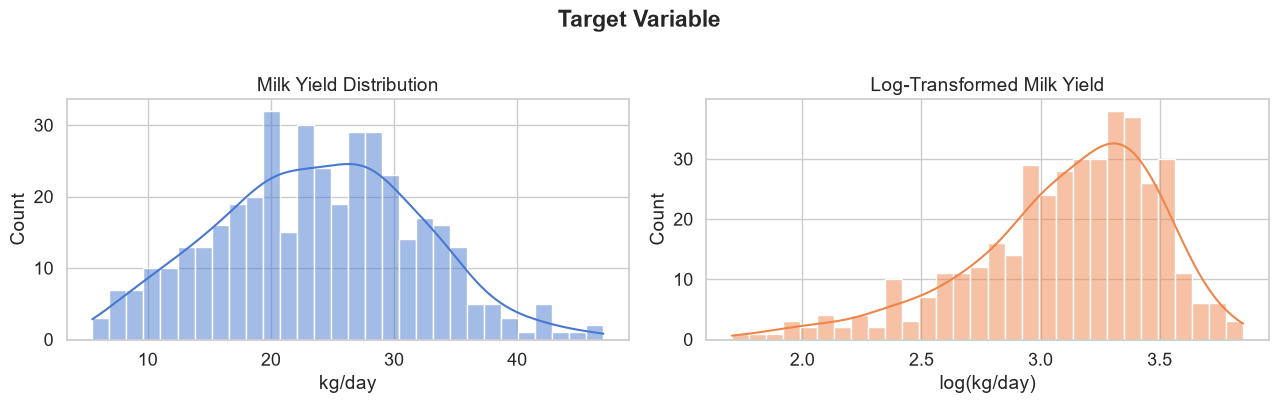

Skewness (raw):  0.059
Skewness (log):  -0.922


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df[TARGET], kde=True, bins=30, ax=axes[0], color=PAL[0])
axes[0].set_title('Milk Yield Distribution')
axes[0].set_xlabel('kg/day')

sns.histplot(np.log(df[TARGET]), kde=True, bins=30, ax=axes[1], color=PAL[1])
axes[1].set_title('Log-Transformed Milk Yield')
axes[1].set_xlabel('log(kg/day)')

plt.suptitle('Target Variable', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness (raw):  {df[TARGET].skew():.3f}")
print(f"Skewness (log):  {np.log(df[TARGET]).skew():.3f}")

### 3d. Scatter Plots vs Key Predictors

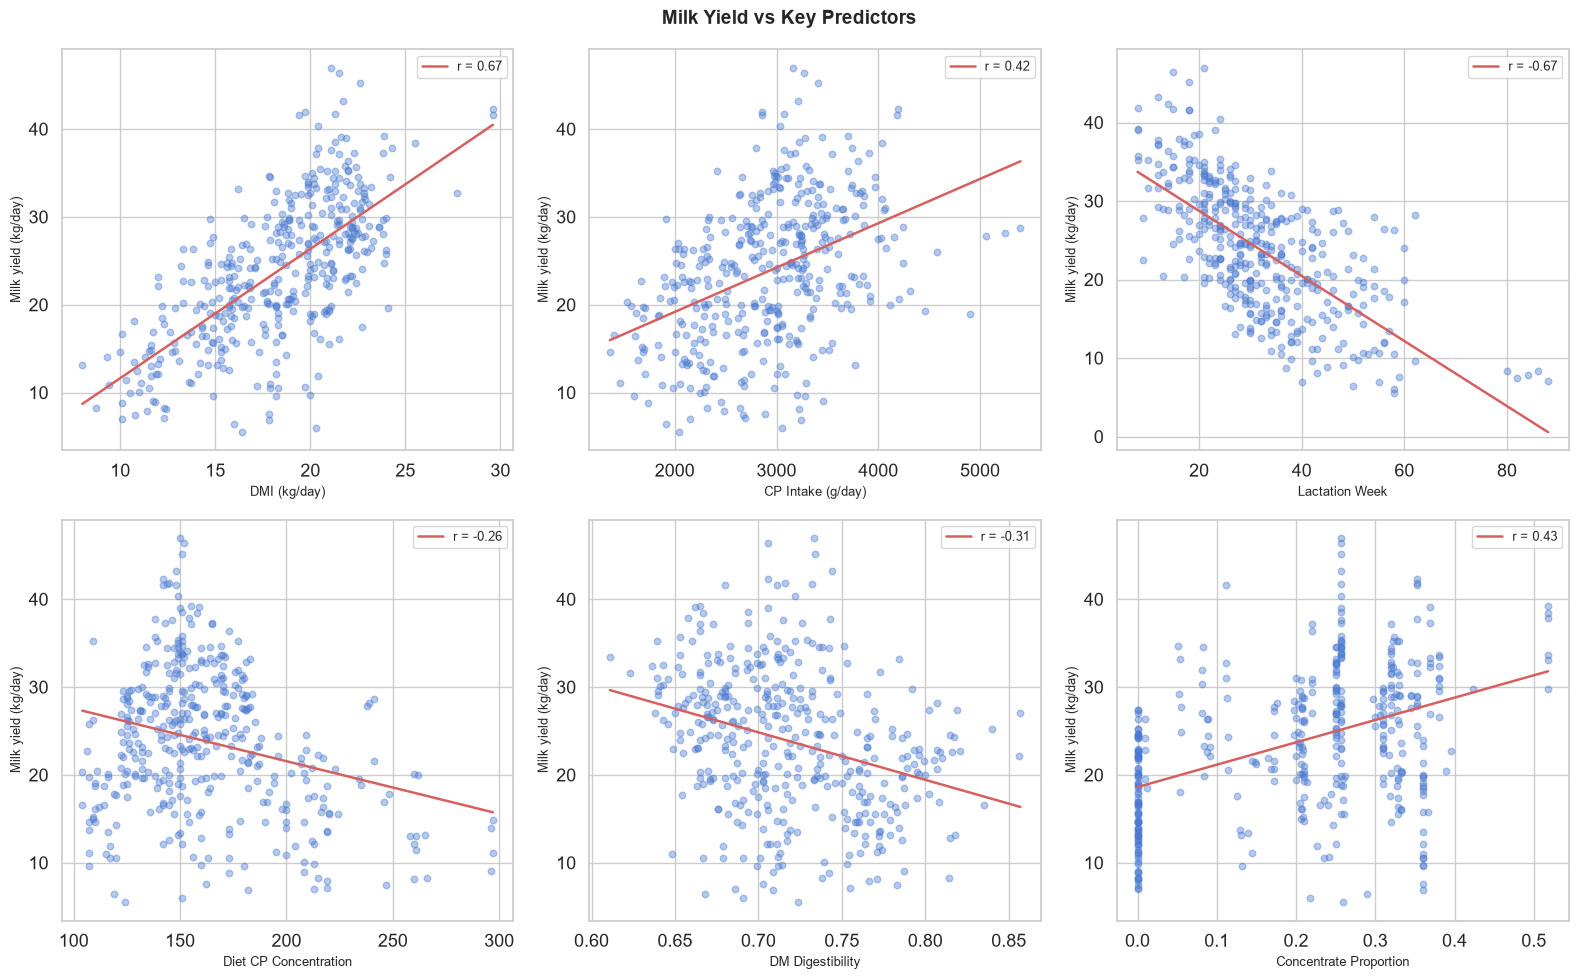

In [8]:
SCATTER_PAIRS = [
    ('4.-DM-intake-(kg/day)',           'DMI (kg/day)'),
    ('4.-CP-intake-(g/day)',             'CP Intake (g/day)'),
    ('2.-Lactation-week',                'Lactation Week'),
    ('4.-Diet-CP-concentration-(g/kg-DM)', 'Diet CP Concentration'),
    ('5.-DM-digestibility-(g/g)',        'DM Digestibility'),
    ('3.-Concentrate-proportion-in-the-diet-(kg/kg,-DM-basis)', 'Concentrate Proportion'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Milk Yield vs Key Predictors', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flat, SCATTER_PAIRS):
    x = df[col].dropna()
    y_plot = df.loc[x.index, TARGET]
    ax.scatter(x, y_plot, alpha=0.4, s=22, color=PAL[0])
    m, b, r, *_ = stats.linregress(x, y_plot)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m*xs+b, color=PAL[3], lw=1.8, label=f'r = {r:.2f}')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Milk yield (kg/day)', fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3e. Yield by Diet Type

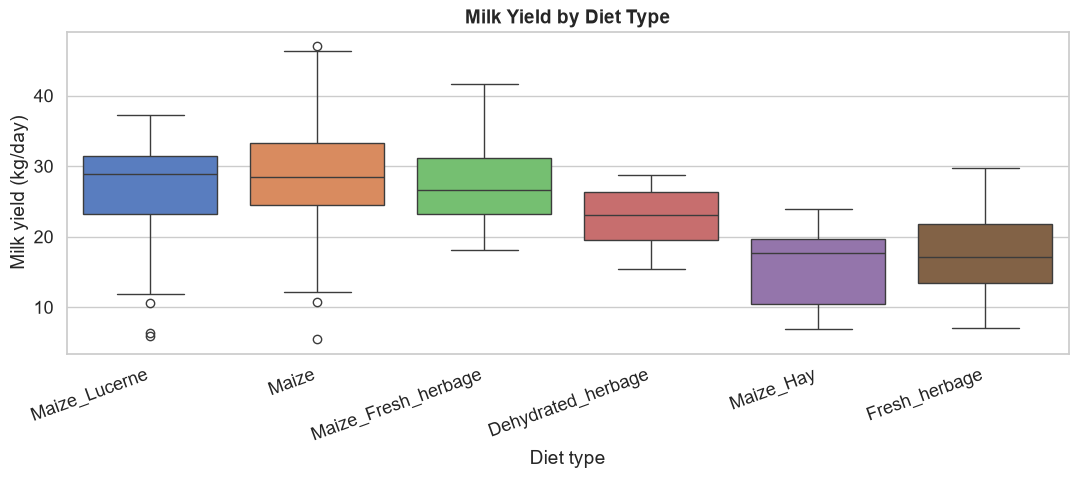

In [9]:
diet_order = df.groupby('3.-Diet-type')[TARGET].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='3.-Diet-type', y=TARGET, order=diet_order, palette='muted', ax=ax)
ax.set_title('Milk Yield by Diet Type', fontweight='bold')
ax.set_xlabel('Diet type')
ax.set_ylabel('Milk yield (kg/day)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 3f. Raw Feature Correlation Heatmap

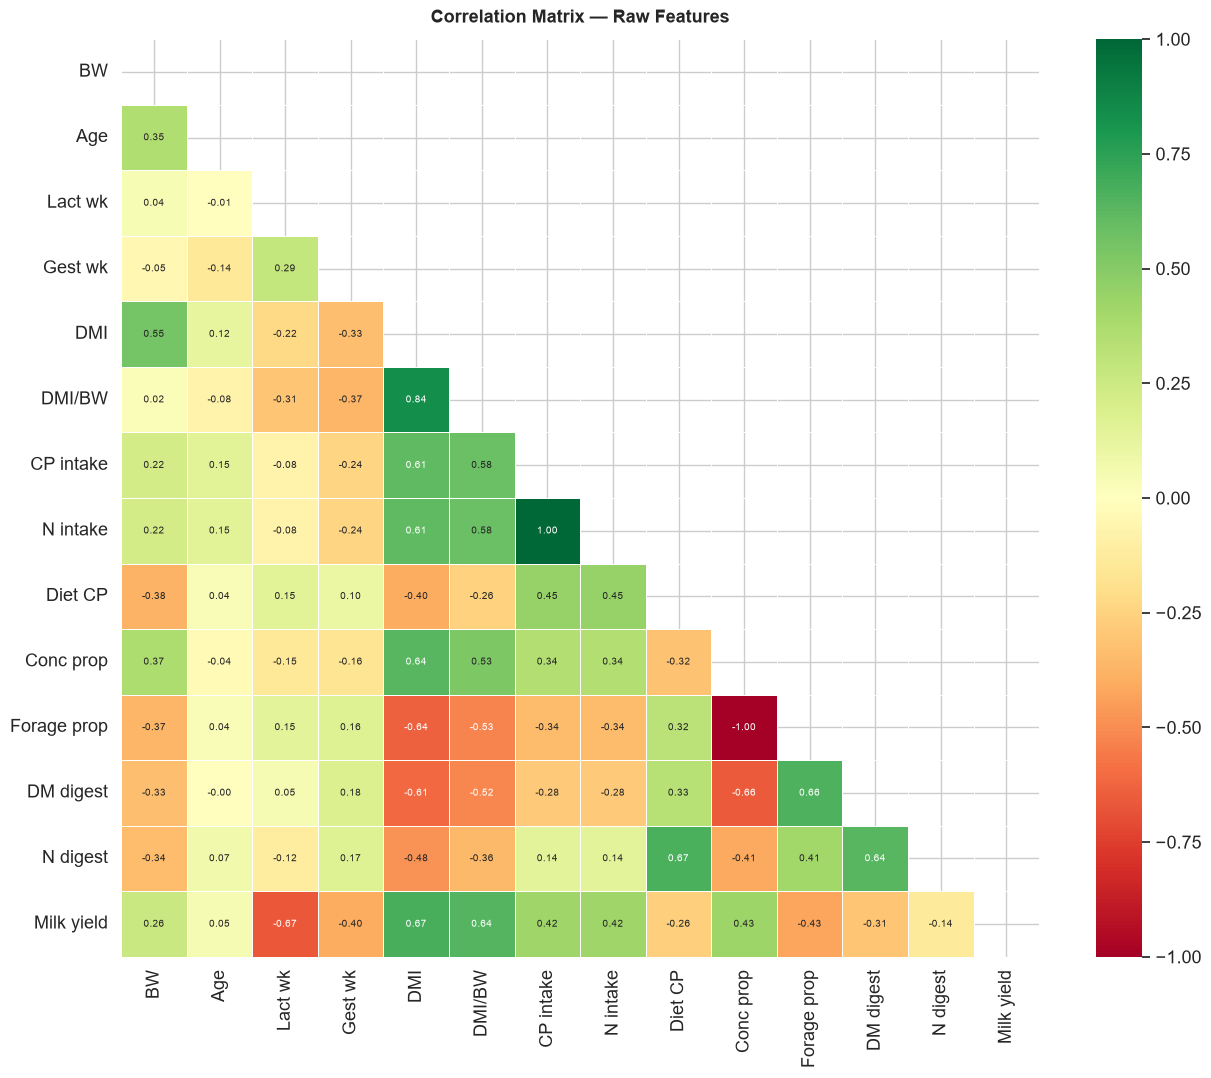

In [10]:
RAW_CORR_COLS = [
    '2.-Body-weight-(kg)', '2.-Cow-age-(month)', '2.-Lactation-week',
    '2.-Gestation-week', '4.-DM-intake-(kg/day)', '4.-DMI-/-100-kg-body-weight',
    '4.-CP-intake-(g/day)', '4.-N-intake-(g/day)',
    '4.-Diet-CP-concentration-(g/kg-DM)',
    '3.-Concentrate-proportion-in-the-diet-(kg/kg,-DM-basis)',
    '3.-Forage-proportion-in-the-diet-(kg/kg,-DM-basis)',
    '5.-DM-digestibility-(g/g)', '5.-N-digestibility-(g/g)',
    TARGET
]

corr_raw = df[RAW_CORR_COLS].corr()
mask = np.triu(np.ones_like(corr_raw, dtype=bool))

# Shorten labels for display
short_labels = [
    'BW', 'Age', 'Lact wk', 'Gest wk', 'DMI', 'DMI/BW',
    'CP intake', 'N intake', 'Diet CP', 'Conc prop', 'Forage prop',
    'DM digest', 'N digest', 'Milk yield'
]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={'size': 7.5}, ax=ax,
            xticklabels=short_labels, yticklabels=short_labels)
ax.set_title('Correlation Matrix — Raw Features', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [11]:
# ── Convenience aliases ───────────────────────────────────────────────────────
BW   = df['2.-Body-weight-(kg)']
AGE  = df['2.-Cow-age-(month)']
LW   = df['2.-Lactation-week']
GW   = df['2.-Gestation-week'].fillna(0)
DMI  = df['4.-DM-intake-(kg/day)']
CPI  = df['4.-CP-intake-(g/day)']
NI   = df['4.-N-intake-(g/day)']
CPc  = df['4.-Diet-CP-concentration-(g/kg-DM)']
CONC = df['3.-Concentrate-proportion-in-the-diet-(kg/kg,-DM-basis)']
FORG = df['3.-Forage-proportion-in-the-diet-(kg/kg,-DM-basis)']
DMDG = df['5.-DM-digestibility-(g/g)']
ND   = df['5.-N-digestibility-(g/g)']

fe = pd.DataFrame(index=df.index)

# ── Raw features ──────────────────────────────────────────────────────────────
fe['BW']               = BW
fe['age_months']       = AGE
fe['lactation_week']   = LW
fe['gestation_week']   = GW
fe['DMI']              = DMI
fe['CP_intake']        = CPI
fe['N_intake']         = NI
fe['diet_CP_conc']     = CPc
fe['conc_prop']        = CONC
fe['forage_prop']      = FORG
fe['DM_digestibility'] = DMDG
fe['N_digestibility']  = ND

# ── Biologically motivated interactions ───────────────────────────────────────
# a * b style
fe['DMI_per_metBW']     = DMI / (BW ** 0.75)    # DMI per metabolic BW (nutrition standard)
fe['CP_per_metBW']      = CPI / (BW ** 0.75)    # CP supply per metabolic BW
fe['dig_CP']            = CPI * ND              # digestible CP proxy
fe['dig_DMI']           = DMI * DMDG            # digestible DM proxy
fe['BW_x_DMI']          = BW * DMI              # energy partitioning interaction
fe['CP_density_x_DMI']  = CPc * DMI             # total CP load from diet concentration

# a / b style
fe['conc_forage_ratio'] = CONC / (FORG + 1e-6)  # concentrate:forage ratio

# a^2 style (nonlinear effects)
fe['lact_week_sq']      = LW ** 2               # Wood's curve concavity
fe['age_sq']            = AGE ** 2              # diminishing returns with age
fe['conc_prop_sq']      = CONC ** 2             # concentrate diminishing returns

# log transform (Wood's model linearisation)
fe['ln_lact_week']      = np.log1p(LW)

# ── Diet type one-hot ─────────────────────────────────────────────────────────
diet_dummies = pd.get_dummies(df['3.-Diet-type'], prefix='diet', drop_first=False)
fe = pd.concat([fe, diet_dummies], axis=1)

# ── Target ────────────────────────────────────────────────────────────────────
fe[TARGET] = df[TARGET].values
fe = fe.dropna(subset=[TARGET]).fillna(fe.median(numeric_only=True))

print(f"Feature matrix shape: {fe.shape}")
print(f"\nEngineered features ({fe.shape[1]-1} total):")
for c in fe.columns:
    if c != TARGET:
        print(f"  {c}")

Feature matrix shape: (402, 30)

Engineered features (29 total):
  BW
  age_months
  lactation_week
  gestation_week
  DMI
  CP_intake
  N_intake
  diet_CP_conc
  conc_prop
  forage_prop
  DM_digestibility
  N_digestibility
  DMI_per_metBW
  CP_per_metBW
  dig_CP
  dig_DMI
  BW_x_DMI
  CP_density_x_DMI
  conc_forage_ratio
  lact_week_sq
  age_sq
  conc_prop_sq
  ln_lact_week
  diet_Dehydrated_herbage
  diet_Fresh_herbage
  diet_Maize
  diet_Maize_Fresh_herbage
  diet_Maize_Hay
  diet_Maize_Lucerne


### Engineered Feature Correlation Heatmap

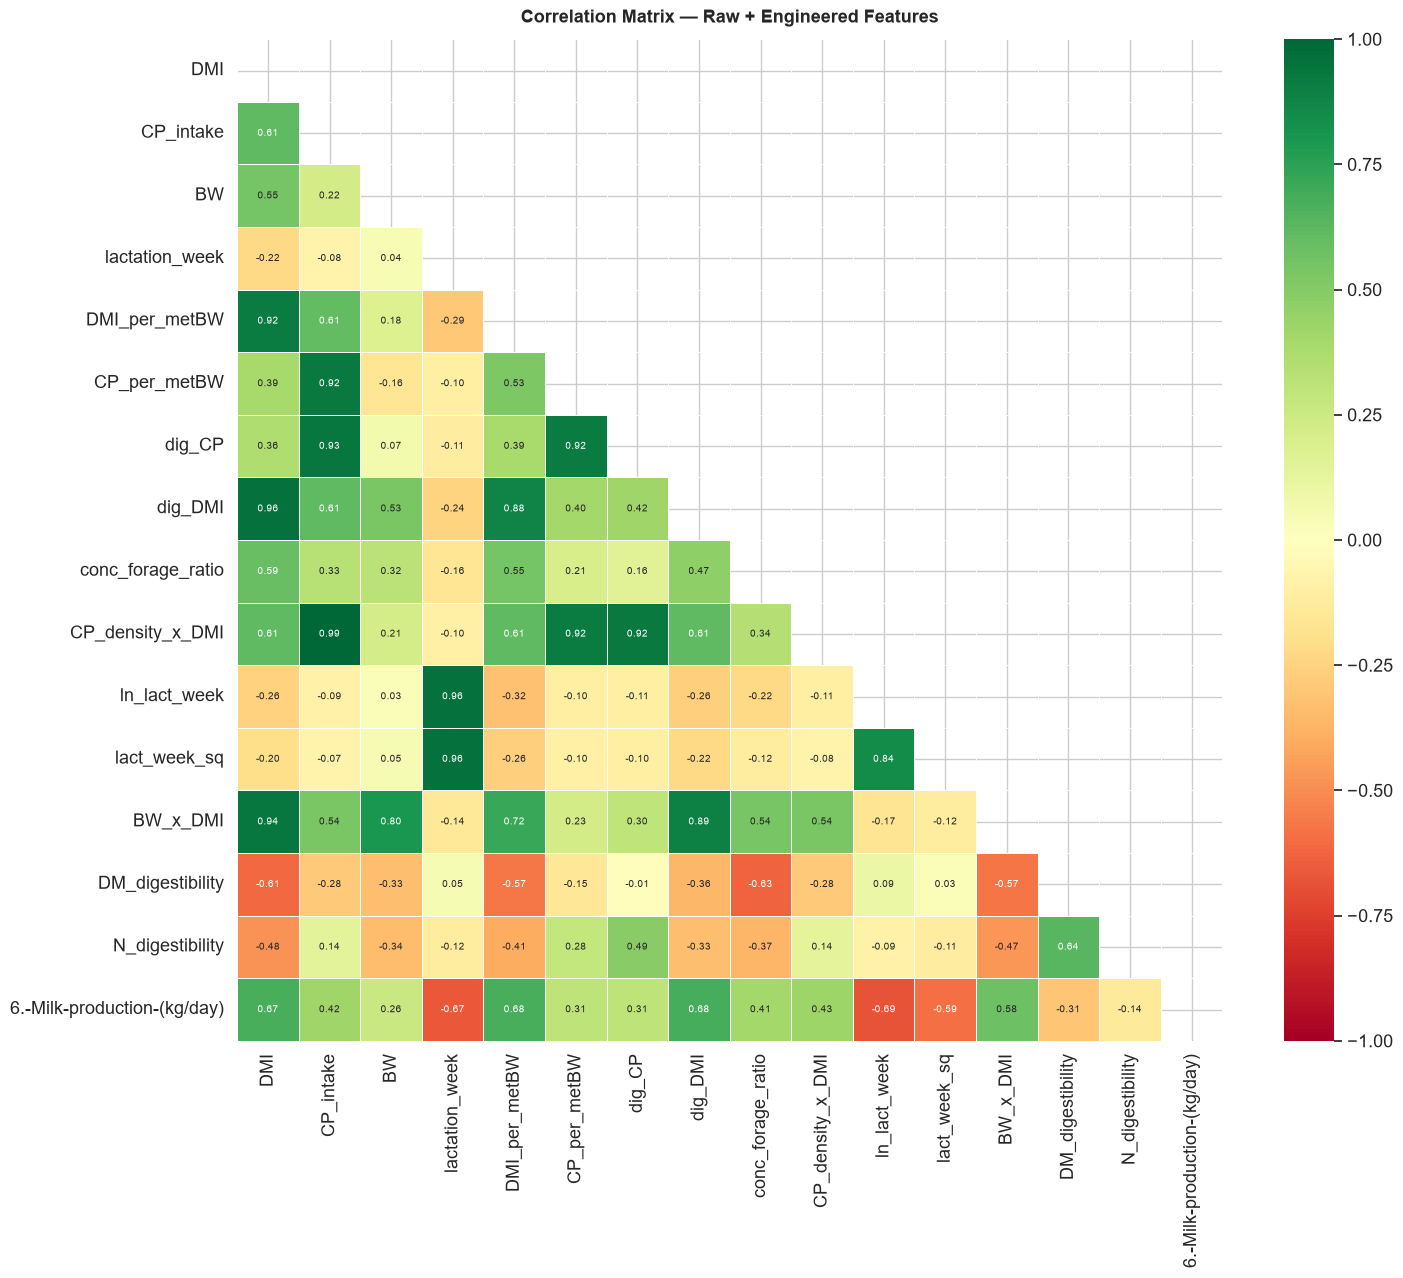

In [12]:
ENG_COLS = [
    'DMI', 'CP_intake', 'BW', 'lactation_week',
    'DMI_per_metBW', 'CP_per_metBW', 'dig_CP', 'dig_DMI',
    'conc_forage_ratio', 'CP_density_x_DMI', 'ln_lact_week',
    'lact_week_sq', 'BW_x_DMI', 'DM_digestibility', 'N_digestibility',
    TARGET
]
corr_eng = fe[ENG_COLS].corr()
mask_e = np.triu(np.ones_like(corr_eng, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr_eng, mask=mask_e, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={'size': 7.5}, ax=ax)
ax.set_title('Correlation Matrix — Raw + Engineered Features', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Correlation with Target — Bar Chart

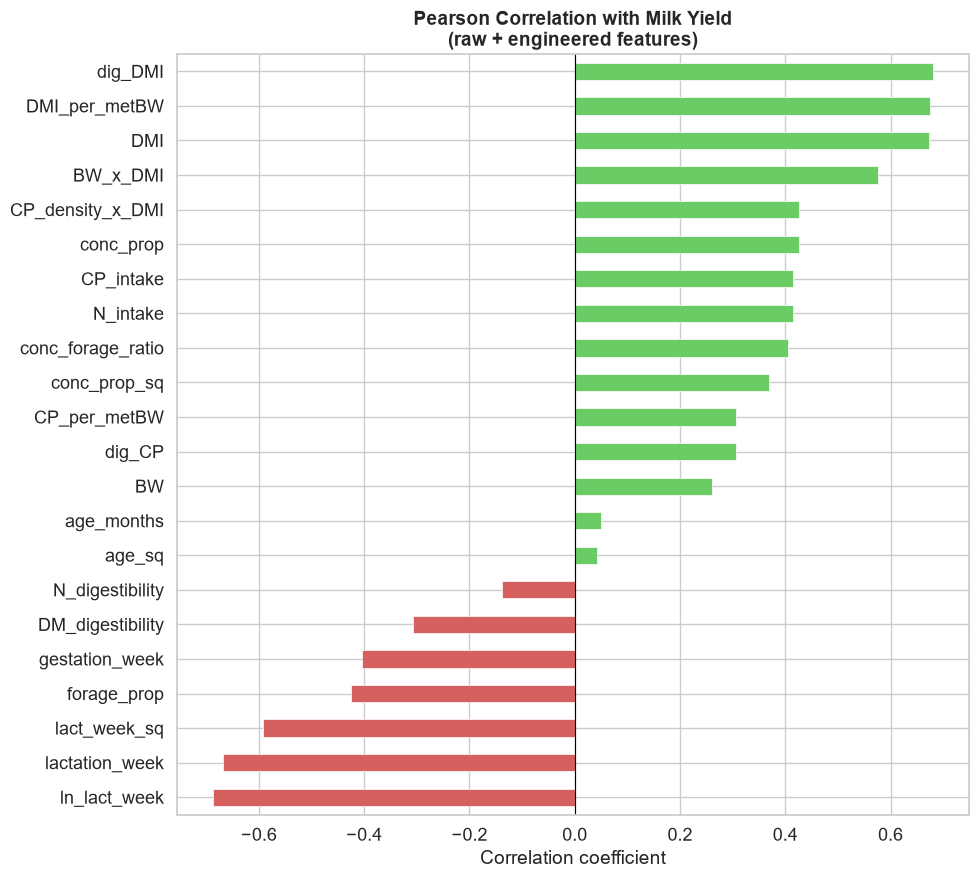

Top 10 correlated features:
ln_lact_week        0.687
dig_DMI             0.680
DMI_per_metBW       0.676
DMI                 0.673
lactation_week      0.667
lact_week_sq        0.593
BW_x_DMI            0.575
CP_density_x_DMI    0.427
conc_prop           0.426
forage_prop         0.426
Name: 6.-Milk-production-(kg/day), dtype: float64


In [13]:
NUM_FEATS = [c for c in fe.columns if c != TARGET and not c.startswith('diet_')]
tgt_corr = fe[NUM_FEATS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors = [PAL[2] if v > 0 else PAL[3] for v in tgt_corr]
tgt_corr.plot(kind='barh', color=colors, ax=ax, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Milk Yield\n(raw + engineered features)', fontweight='bold')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print("Top 10 correlated features:")
print(tgt_corr.abs().sort_values(ascending=False).head(10).round(3))

## 5. Prepare ML Data

In [14]:
FEATURE_COLS = [c for c in fe.columns if c != TARGET]
X = fe[FEATURE_COLS].copy().astype(float)
y = fe[TARGET].copy()

CV = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    if label:
        print(f"{label:30s} RMSE={rmse:.3f}  R²={r2:.3f}  MAE={mae:.3f}")
    return rmse, r2, mae

print(f"X shape: {X.shape}")
print(f"y: {y.min():.1f} – {y.max():.1f} kg/day  (mean {y.mean():.2f})")

X shape: (402, 29)
y: 5.5 – 47.0 kg/day  (mean 23.83)


## 6. Baseline Models (default hyperparameters)

In [15]:
RESULTS = {}  # will accumulate all model results

baseline_models = {
    'Ridge (default)':    Pipeline([('s', StandardScaler()), ('m', Ridge())]),
    'Lasso (default)':    Pipeline([('s', StandardScaler()), ('m', Lasso(max_iter=5000))]),
    'XGBoost (default)':  xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM (default)': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
}

print("── Baseline 5-fold CV ──────────────────────────────────────────────────")
for name, model in baseline_models.items():
    oof = cross_val_predict(model, X, y, cv=CV)
    rmse, r2, mae = evaluate(y, oof, name)
    RESULTS[name] = {'RMSE': rmse, 'R2': r2, 'MAE': mae, 'OOF': oof}

── Baseline 5-fold CV ──────────────────────────────────────────────────
Ridge (default)                RMSE=3.854  R²=0.776  MAE=2.934
Lasso (default)                RMSE=4.278  R²=0.724  MAE=3.378
XGBoost (default)              RMSE=3.468  R²=0.819  MAE=2.685
LightGBM (default)             RMSE=3.280  R²=0.838  MAE=2.506


## 7. Hyperparameter Tuning

### 7a. Ridge

In [16]:
ridge_gs = GridSearchCV(
    Pipeline([('s', StandardScaler()), ('m', Ridge())]),
    param_grid={'m__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=CV, scoring='neg_mean_squared_error', n_jobs=-1
)
ridge_gs.fit(X, y)
best_ridge_alpha = ridge_gs.best_params_['m__alpha']
print(f"Best Ridge alpha: {best_ridge_alpha}")

ridge_tuned = Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=best_ridge_alpha))])
oof_ridge = cross_val_predict(ridge_tuned, X, y, cv=CV)
rmse, r2, mae = evaluate(y, oof_ridge, f'Ridge (α={best_ridge_alpha})')
RESULTS['Ridge (tuned)'] = {'RMSE': rmse, 'R2': r2, 'MAE': mae, 'OOF': oof_ridge}
ridge_tuned.fit(X, y)

Best Ridge alpha: 0.01
Ridge (α=0.01)                 RMSE=3.768  R²=0.786  MAE=2.848


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('s', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['BW','age_months','lactation_week',...,'diet_Maize_Fresh_herbage', 'diet_Maize_Hay','diet_Maize_Lucerne']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


### 7b. Lasso

In [17]:
lasso_gs = GridSearchCV(
    Pipeline([('s', StandardScaler()), ('m', Lasso(max_iter=10000))]),
    param_grid={'m__alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]},
    cv=CV, scoring='neg_mean_squared_error', n_jobs=-1
)
lasso_gs.fit(X, y)
best_lasso_alpha = lasso_gs.best_params_['m__alpha']
print(f"Best Lasso alpha: {best_lasso_alpha}")

lasso_tuned = Pipeline([('s', StandardScaler()), ('m', Lasso(alpha=best_lasso_alpha, max_iter=10000))])
oof_lasso = cross_val_predict(lasso_tuned, X, y, cv=CV)
rmse, r2, mae = evaluate(y, oof_lasso, f'Lasso (α={best_lasso_alpha})')
RESULTS['Lasso (tuned)'] = {'RMSE': rmse, 'R2': r2, 'MAE': mae, 'OOF': oof_lasso}
lasso_tuned.fit(X, y)

# Show which features Lasso zeroed out
coefs = pd.Series(lasso_tuned.named_steps['m'].coef_, index=X.columns)
selected = coefs[coefs != 0].sort_values(key=abs, ascending=False)
zeroed   = coefs[coefs == 0]
print(f"\nLasso selected {len(selected)} / {len(coefs)} features  (zeroed {len(zeroed)})")
print(selected.round(4).to_string())

Best Lasso alpha: 0.001
Lasso (α=0.001)                RMSE=3.752  R²=0.788  MAE=2.834

Lasso selected 25 / 29 features  (zeroed 4)
DMI                         33.8819
lactation_week             -20.2416
DMI_per_metBW              -17.1501
BW_x_DMI                   -16.6029
lact_week_sq                 9.9825
dig_CP                      -8.3701
ln_lact_week                 6.6924
N_intake                     3.9381
N_digestibility              2.8365
CP_per_metBW                 2.3728
dig_DMI                      1.9929
diet_Fresh_herbage          -1.7734
CP_density_x_DMI             1.3263
BW                          -1.1869
DM_digestibility             1.0475
diet_Dehydrated_herbage      0.4298
age_months                   0.4064
conc_prop                    0.3723
diet_Maize_Fresh_herbage     0.3665
diet_Maize_Hay              -0.3621
age_sq                      -0.1201
gestation_week              -0.1127
conc_forage_ratio            0.1095
diet_CP_conc                 0.0666
diet

### 7c. XGBoost

In [18]:
xgb_param_dist = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.07, 0.1],
    'subsample':        [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha':        [0, 0.05, 0.1],
    'reg_lambda':       [1, 2, 3],
    'min_child_weight': [1, 3],
}

N_ITER = 80  # 80 random combos × 5 folds = 400 fits, ~3-5 min

xgb_gs = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=N_ITER,
    cv=CV,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,          # silence sklearn's own output, tqdm handles it
    random_state=42,
)

# ── progress bar (polls fitted estimators count every 2s) ─────────────────────
total_fits = N_ITER * CV.n_splits
pbar = tqdm(total=total_fits, desc='XGB RandomizedSearch', unit='fit')

def _watch(gs, pbar):
    last = 0
    while not hasattr(gs, 'best_params_'):
        current = len(gs.cv_results_['params']) * CV.n_splits if hasattr(gs, 'cv_results_') else 0
        pbar.update(current - last)
        last = current
        time.sleep(2)
    pbar.update(total_fits - pbar.n)  # fill to 100%
    pbar.close()

t = threading.Thread(target=_watch, args=(xgb_gs, pbar), daemon=True)
t.start()

xgb_gs.fit(X, y)
t.join()

print(f"\nBest XGB params:\n{xgb_gs.best_params_}")
print(f"Best CV RMSE: {(-xgb_gs.best_score_)**0.5:.3f}")

xgb_tuned = xgb.XGBRegressor(**xgb_gs.best_params_, random_state=42, n_jobs=-1, verbosity=0)
oof_xgb = cross_val_predict(xgb_tuned, X, y, cv=CV)
rmse, r2, mae = evaluate(y, oof_xgb, 'XGBoost (tuned)')
RESULTS['XGBoost (tuned)'] = {'RMSE': rmse, 'R2': r2, 'MAE': mae, 'OOF': oof_xgb}
xgb_tuned.fit(X, y)

XGB RandomizedSearch: 100%|██████████| 400/400 [00:16<00:00, 24.22fit/s] 



Best XGB params:
{'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.07, 'colsample_bytree': 1.0}
Best CV RMSE: 3.051
XGBoost (tuned)                RMSE=3.080  R²=0.857  MAE=2.340


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 7d. LightGBM

In [19]:
lgb_param_dist = {
    'n_estimators':       [300, 500, 700],
    'max_depth':          [3, 4, 5, 6],
    'learning_rate':      [0.03, 0.07, 0.1],
    'num_leaves':         [15, 31, 63],
    'subsample':          [0.7, 0.85, 1.0],
    'reg_alpha':          [0, 0.05, 0.1],
    'reg_lambda':         [0, 1, 2],
    'min_child_samples':  [5, 10, 20],
}

N_ITER = 80  # adjust as desired

lgb_gs = RandomizedSearchCV(
    lgb.LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    lgb_param_dist,
    n_iter=N_ITER,
    cv=CV,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
    random_state=42,
)

# ── progress bar ─────────────────────────────────────────────
total_fits = N_ITER * CV.n_splits
pbar = tqdm(total=total_fits, desc='LGB RandomizedSearch', unit='fit')

def _watch(gs, pbar):
    last = 0
    while not hasattr(gs, 'best_params_'):
        current = (
            len(gs.cv_results_['params']) * CV.n_splits
            if hasattr(gs, 'cv_results_')
            else 0
        )
        pbar.update(current - last)
        last = current
        time.sleep(2)

    pbar.update(total_fits - pbar.n)
    pbar.close()

t = threading.Thread(target=_watch, args=(lgb_gs, pbar), daemon=True)
t.start()

lgb_gs.fit(X, y)
t.join()

print(f"\nBest LGB params:\n{lgb_gs.best_params_}")
print(f"Best CV RMSE: {(-lgb_gs.best_score_)**0.5:.3f}")

lgb_tuned = lgb.LGBMRegressor(
    **lgb_gs.best_params_,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

oof_lgb = cross_val_predict(lgb_tuned, X, y, cv=CV)

rmse, r2, mae = evaluate(y, oof_lgb, 'LightGBM (tuned)')
RESULTS['LightGBM (tuned)'] = {
    'RMSE': rmse,
    'R2': r2,
    'MAE': mae,
    'OOF': oof_lgb
}

lgb_tuned.fit(X, y)

LGB RandomizedSearch: 100%|██████████| 400/400 [04:20<00:00,  1.53fit/s] 



Best LGB params:
{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0.05, 'num_leaves': 15, 'n_estimators': 700, 'min_child_samples': 5, 'max_depth': 6, 'learning_rate': 0.07}
Best CV RMSE: 3.086
LightGBM (tuned)               RMSE=3.084  R²=0.856  MAE=2.369


,num_leaves,15
,max_depth,6
,learning_rate,0.07
,n_estimators,700
,min_child_samples,5
,reg_alpha,0.05
,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,subsample_for_bin,200000


## 8. Stacking Ensemble
**Idea:** Use out-of-fold predictions from each tuned base model as *additional input features* 
for a meta-learner (Ridge). This gives the meta-learner visibility into what each base model 
thinks, on top of the original features — typically 0.5–2 RMSE points better than any single model.

The flow:
1. Generate OOF predictions for each base model (already done above)
2. Build a new feature matrix `X_stack = [X_original | oof_ridge | oof_lasso | oof_xgb | oof_lgb]`
3. Train a Ridge meta-learner on `X_stack → y`
4. Evaluate via another 5-fold CV pass on `X_stack`

In [20]:
# ── Build stacking feature matrix ─────────────────────────────────────────────
X_stack = X.copy()
X_stack['meta_ridge'] = oof_ridge
X_stack['meta_lasso'] = oof_lasso
X_stack['meta_xgb']   = oof_xgb
X_stack['meta_lgb']   = oof_lgb

print(f"Stacking feature matrix: {X_stack.shape}  (original {X.shape[1]} + 4 meta-features)")

Stacking feature matrix: (402, 33)  (original 29 + 4 meta-features)


In [21]:
# ── Meta-learner: Ridge with tuning ──────────────────────────────────────────
meta_gs = GridSearchCV(
    Pipeline([('s', StandardScaler()), ('m', Ridge())]),
    param_grid={'m__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]},
    cv=CV, scoring='neg_mean_squared_error', n_jobs=-1
)
meta_gs.fit(X_stack, y)
best_meta_alpha = meta_gs.best_params_['m__alpha']
print(f"Best meta-learner alpha: {best_meta_alpha}")

meta_ridge = Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=best_meta_alpha))])
oof_stack = cross_val_predict(meta_ridge, X_stack, y, cv=CV)
rmse, r2, mae = evaluate(y, oof_stack, f'Stack→Ridge (α={best_meta_alpha})')
RESULTS['Stacking (Ridge meta)'] = {'RMSE': rmse, 'R2': r2, 'MAE': mae, 'OOF': oof_stack}
meta_ridge.fit(X_stack, y)

Best meta-learner alpha: 0.01
Stack→Ridge (α=0.01)           RMSE=2.785  R²=0.883  MAE=2.119


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('s', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['BW','age_months','lactation_week',...,'meta_lasso','meta_xgb','meta_lgb']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [22]:
# ── Meta-learner: LightGBM (nonlinear meta) ───────────────────────────────────
lgb_meta_gs = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid={
        'n_estimators': [100, 200, 300],
        'max_depth':    [2, 3, 4],
        'learning_rate':[0.03, 0.07, 0.1],
        'num_leaves':   [7, 15, 31],
    },
    cv=CV, scoring='neg_mean_squared_error', n_jobs=-1
)
lgb_meta_gs.fit(X_stack, y)
print(f"Best LGB meta params: {lgb_meta_gs.best_params_}")

lgb_meta = lgb.LGBMRegressor(**lgb_meta_gs.best_params_, random_state=42, n_jobs=-1, verbose=-1)
oof_stack_lgb = cross_val_predict(lgb_meta, X_stack, y, cv=CV)
rmse, r2, mae = evaluate(y, oof_stack_lgb, 'Stacking (LGB meta)')
RESULTS['Stacking (LGB meta)'] = {'RMSE': rmse, 'R2': r2, 'MAE': mae, 'OOF': oof_stack_lgb}
lgb_meta.fit(X_stack, y)

Best LGB meta params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100, 'num_leaves': 7}
Stacking (LGB meta)            RMSE=3.330  R²=0.833  MAE=2.561


,num_leaves,7
,max_depth,2
,learning_rate,0.03
,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [23]:
# ── Weighted blend of stack outputs ──────────────────────────────────────────
best_blend_rmse = 1e9
best_w_blend    = None

for w_r in np.arange(0.0, 1.01, 0.1):
    w_l = 1.0 - w_r
    blend = w_r * oof_stack + w_l * oof_stack_lgb
    rmse  = np.sqrt(mean_squared_error(y, blend))
    if rmse < best_blend_rmse:
        best_blend_rmse = rmse
        best_w_blend    = (w_r, w_l)

wr, wl = best_w_blend
oof_blend = wr * oof_stack + wl * oof_stack_lgb
rmse, r2, mae = evaluate(y, oof_blend, f'Stack blend (Ridge×{wr:.1f} + LGB×{wl:.1f})')
RESULTS['Stack blend'] = {'RMSE': rmse, 'R2': r2, 'MAE': mae, 'OOF': oof_blend}

Stack blend (Ridge×1.0 + LGB×0.0) RMSE=2.785  R²=0.883  MAE=2.119


## 9. Evaluation & Comparison

In [24]:
groups = {
    'DEFAULT MODELS': [
        'Ridge (default)',
        'Lasso (default)',
        'XGBoost (default)',
        'LightGBM (default)',
    ],
    'TUNED MODELS': [
        'Ridge (tuned)',
        'Lasso (tuned)',
        'XGBoost (tuned)',
        'LightGBM (tuned)',
    ],
    'ENSEMBLES / META LEARNERS': [
        'Stacking (LGB meta)',
        'Stacking (Ridge meta)',
        'Stack blend',
    ]
}

results_df = pd.DataFrame({
    'Model': list(RESULTS.keys()),
    'RMSE': [v['RMSE'] for v in RESULTS.values()],
    'R2':   [v['R2']   for v in RESULTS.values()],
    'MAE':  [v['MAE']  for v in RESULTS.values()],
})

print("=" * 65)
print(f"{'Model':<35} {'RMSE':>8} {'R²':>8} {'MAE':>8}")
print("=" * 65)

for group_name, models in groups.items():
    print(f"\n--- {group_name} ---")

    for model in models:
        row = results_df[results_df['Model'] == model]

        if len(row):
            row = row.iloc[0]
            print(
                f"{row['Model']:<35}"
                f"{row['RMSE']:>8.3f}"
                f"{row['R2']:>8.3f}"
                f"{row['MAE']:>8.3f}"
            )

print("\n" + "=" * 65)

results_df

Model                                   RMSE       R²      MAE

--- DEFAULT MODELS ---
Ridge (default)                       3.854   0.776   2.934
Lasso (default)                       4.278   0.724   3.378
XGBoost (default)                     3.468   0.819   2.685
LightGBM (default)                    3.280   0.838   2.506

--- TUNED MODELS ---
Ridge (tuned)                         3.768   0.786   2.848
Lasso (tuned)                         3.752   0.788   2.834
XGBoost (tuned)                       3.080   0.857   2.340
LightGBM (tuned)                      3.084   0.856   2.369

--- ENSEMBLES / META LEARNERS ---


Stacking (LGB meta)                   3.330   0.833   2.561
Stacking (Ridge meta)                 2.785   0.883   2.119
Stack blend                           2.785   0.883   2.119



,Model,RMSE,R2,MAE
0,Ridge (default),3.854309,0.775860,2.934132
1,Lasso (default),4.278443,0.723816,3.378288
2,XGBoost (default),3.468080,0.818530,2.685340
3,LightGBM (default),3.279600,0.837719,2.505908
4,Ridge (tuned),3.768424,0.785737,2.848368
5,Lasso (tuned),3.752265,0.787571,2.833992
6,XGBoost (tuned),3.080257,0.856847,2.340044
7,LightGBM (tuned),3.084249,0.856476,2.369336
8,Stacking (Ridge meta),2.785391,0.882942,2.118619
9,Stacking (LGB meta),3.329648,0.832728,2.561465


### Model Comparison Charts

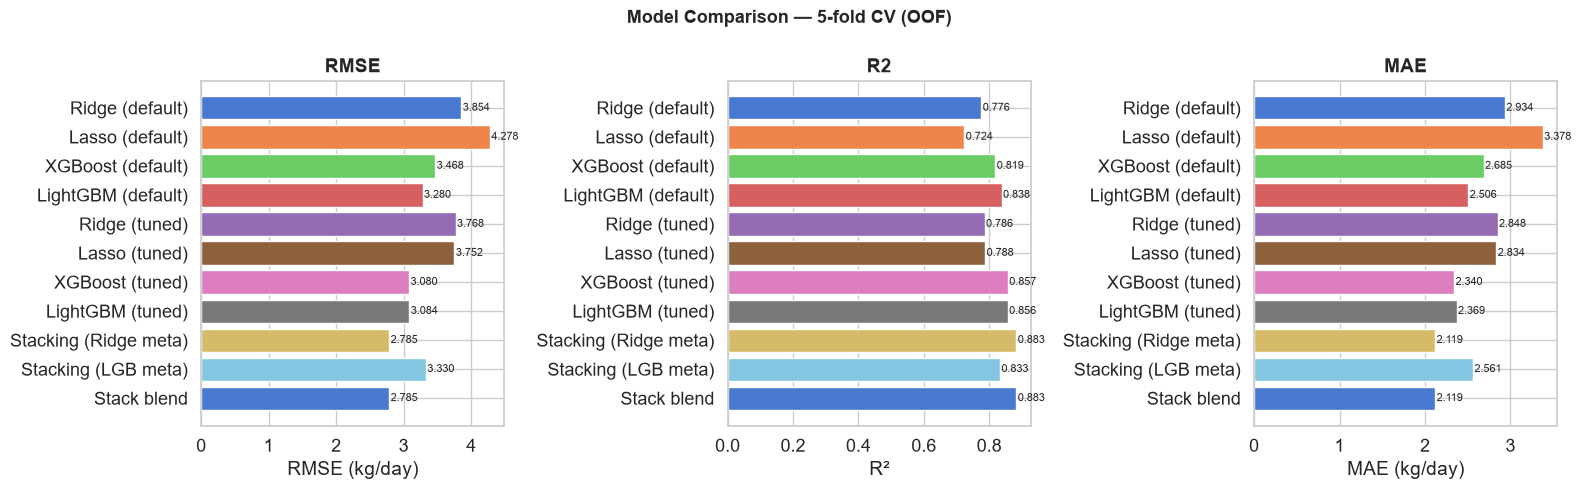

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — 5-fold CV (OOF)', fontsize=13, fontweight='bold')

colors = sns.color_palette("muted", len(results_df))
for ax, (metric, ylabel) in zip(axes, [('RMSE','RMSE (kg/day)'),('R2','R²'),('MAE','MAE (kg/day)')]):
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(ylabel)
    ax.invert_yaxis()
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_width() + 0.005 * results_df[metric].max(),
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### Actual vs Predicted — Best Model

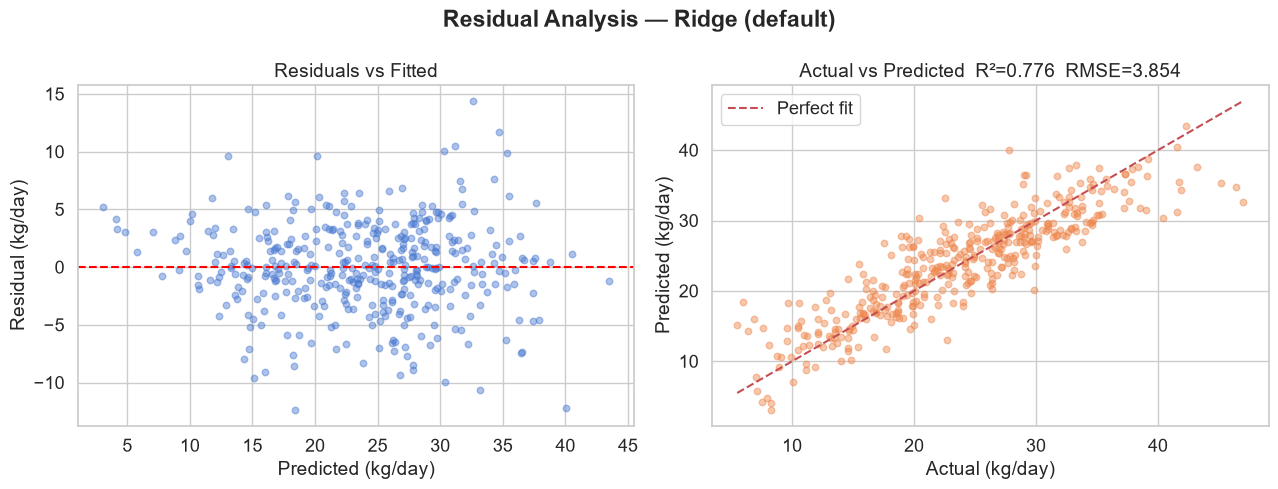

In [26]:
best_name = results_df.iloc[0]['Model']
best_oof  = RESULTS[best_name]['OOF']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Residual Analysis — {best_name}', fontweight='bold')

residuals = y.values - best_oof

axes[0].scatter(best_oof, residuals, alpha=0.45, s=22, color=PAL[0])
axes[0].axhline(0, color='red', lw=1.5, ls='--')
axes[0].set_xlabel('Predicted (kg/day)')
axes[0].set_ylabel('Residual (kg/day)')
axes[0].set_title('Residuals vs Fitted')

mn, mx = y.min(), y.max()
axes[1].scatter(y, best_oof, alpha=0.45, s=22, color=PAL[1])
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual (kg/day)')
axes[1].set_ylabel('Predicted (kg/day)')
axes[1].set_title(f'Actual vs Predicted  R²={r2_score(y, best_oof):.3f}  RMSE={np.sqrt(mean_squared_error(y, best_oof)):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Feature Importance — XGBoost & LightGBM

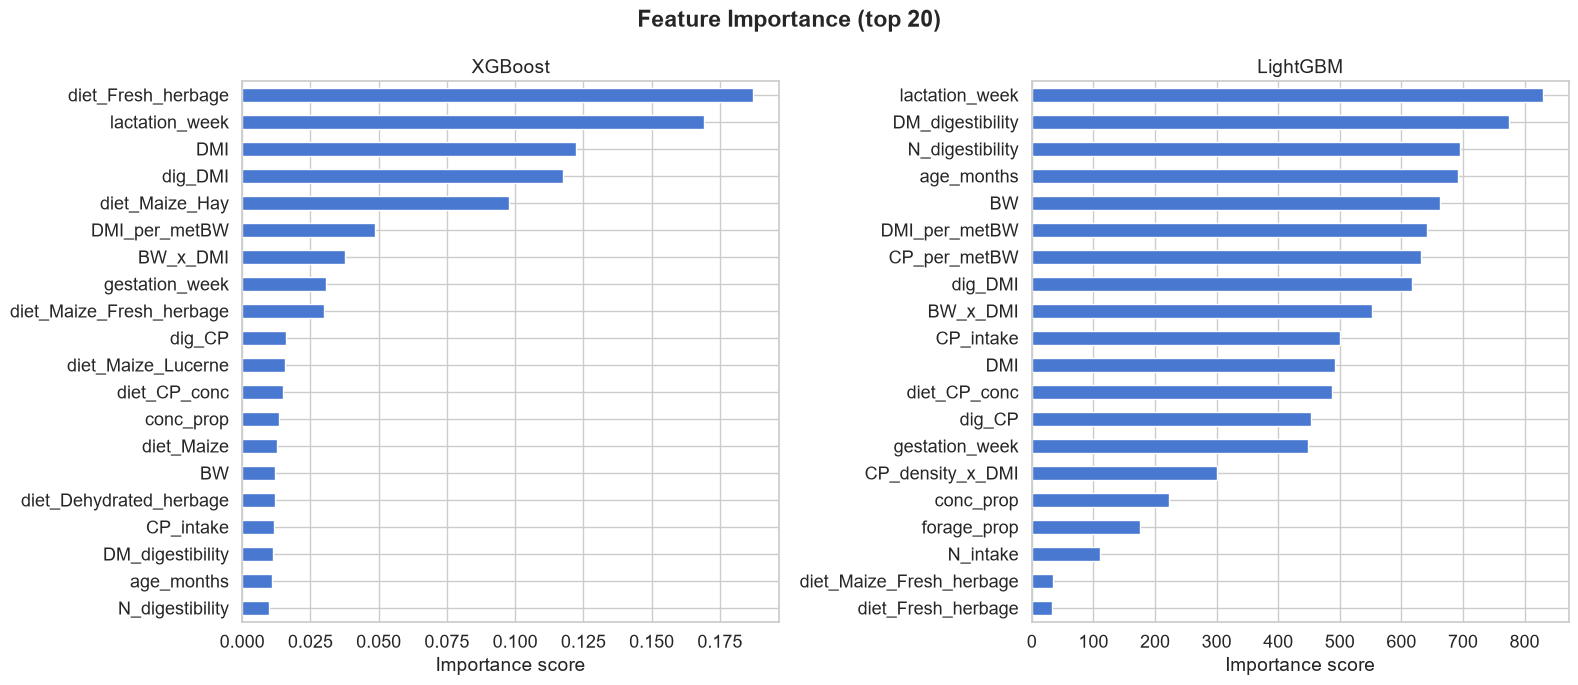

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance (top 20)', fontweight='bold')

for ax, (model, label) in zip(axes, [(xgb_tuned, 'XGBoost'), (lgb_tuned, 'LightGBM')]):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(20)
    imp.plot(kind='barh', ax=ax, color=PAL[0], edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Importance score')

plt.tight_layout()
plt.show()

### Meta-Feature Weights (Stacking Ridge)

Top 15 features by |coefficient| in the Ridge meta-learner:
DMI                   81.2620
lactation_week       -45.0391
DMI_per_metBW        -44.6746
BW_x_DMI             -38.0031
lact_week_sq          22.4403
dig_CP               -19.7795
meta_ridge           -16.9226
ln_lact_week          14.5178
N_intake               8.8948
CP_per_metBW           8.1131
N_digestibility        6.6034
dig_DMI                5.1617
BW                    -4.2165
CP_density_x_DMI       4.0636
diet_Fresh_herbage    -3.2860


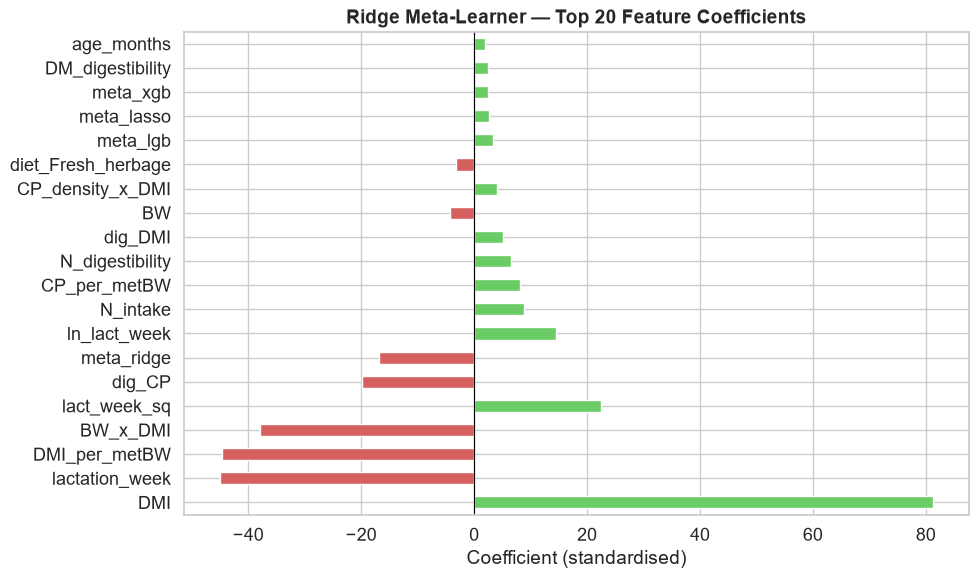

In [28]:
# Extract meta-learner coefficients from the stacking Ridge
meta_coefs = pd.Series(
    meta_ridge.named_steps['m'].coef_,
    index=X_stack.columns
).sort_values(key=abs, ascending=False)

print("Top 15 features by |coefficient| in the Ridge meta-learner:")
print(meta_coefs.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top_coefs = meta_coefs.head(20)
colors_c = [PAL[2] if v > 0 else PAL[3] for v in top_coefs.values]
top_coefs.plot(kind='barh', ax=ax, color=colors_c, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Ridge Meta-Learner — Top 20 Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (standardised)')
plt.tight_layout()
plt.show()

## 10. SHAP Explainability

The deployed model is the **Ridge meta-learner**, which blends four base models
(Ridge, Lasso, XGBoost, LightGBM) plus the original engineered features. A farmer
doesn't care about "meta_xgb = 34.2" — they care about *body weight, DMI, lactation
week*, etc. So the goal here is to trace SHAP attributions **all the way back through
the stack to the original, farm-facing features**, exactly (not approximated).

**Approach:**
- **XGBoost / LightGBM** → `shap.TreeExplainer` (exact for tree ensembles).
- **Ridge / Lasso** → closed-form linear SHAP (a linear model's SHAP value for a
  feature is just `coefficient × (value − baseline)`; no sampling needed).
- **Meta-learner (Ridge)** → same closed-form trick, but its "features" include the
  four base models' predictions. Since those predictions are themselves linear
  combinations of the base SHAP values (chain rule), we substitute each meta-feature's
  contribution with `meta_coefficient × that base model's SHAP vector`. The result is
  an **exact** decomposition of the final prediction into original features — we
  verify this with a reconstruction check below.

### 10a. Setup

In [29]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '--quiet'])
    import shap

print(f"shap version: {shap.__version__}")

shap version: 0.52.0


### 10b. Closed-form SHAP for linear base models (Ridge, Lasso)

In [30]:
def linear_shap(pipeline, X_df):
    """
    Exact SHAP values for a (StandardScaler -> Ridge/Lasso) sklearn Pipeline.
    Baseline = column means of X_df (standard SHAP interventional baseline).
    Returns: (shap_values DataFrame [n x p], base_value float, raw_coef array [p])
      where raw_coef[j] = d(prediction)/d(raw feature j)
    """
    scaler = pipeline.named_steps['s']
    model  = pipeline.named_steps['m']

    raw_coef = model.coef_ / scaler.scale_                       # per-raw-unit slope
    xbar     = X_df.mean(axis=0).values
    eff_intercept = model.intercept_ - np.sum(model.coef_ * scaler.mean_ / scaler.scale_)

    contrib    = (X_df.values - xbar) * raw_coef                 # (n, p)
    base_value = float(eff_intercept + np.sum(raw_coef * xbar))  # = prediction(xbar)

    shap_df = pd.DataFrame(contrib, index=X_df.index, columns=X_df.columns)
    return shap_df, base_value, raw_coef


shap_ridge_df, base_ridge, coef_ridge_raw = linear_shap(ridge_tuned, X)
shap_lasso_df, base_lasso, coef_lasso_raw = linear_shap(lasso_tuned, X)

print(f"Ridge  base value: {base_ridge:.3f} kg/day")
print(f"Lasso  base value: {base_lasso:.3f} kg/day")

Ridge  base value: 23.830 kg/day
Lasso  base value: 23.830 kg/day


### 10c. TreeExplainer SHAP for XGBoost & LightGBM

In [31]:
xgb_explainer = shap.TreeExplainer(xgb_tuned)
shap_xgb_vals = xgb_explainer.shap_values(X)
shap_xgb_df   = pd.DataFrame(shap_xgb_vals, index=X.index, columns=X.columns)
base_xgb      = float(xgb_explainer.expected_value)

lgb_explainer = shap.TreeExplainer(lgb_tuned)
shap_lgb_vals = lgb_explainer.shap_values(X)
shap_lgb_df   = pd.DataFrame(shap_lgb_vals, index=X.index, columns=X.columns)
base_lgb      = float(lgb_explainer.expected_value)

print(f"XGBoost   base value: {base_xgb:.3f} kg/day")
print(f"LightGBM  base value: {base_lgb:.3f} kg/day")

XGBoost   base value: 23.693 kg/day
LightGBM  base value: 23.830 kg/day


### 10d. Propagate through the meta-learner (chain rule)

Every column of `X_stack` is either (a) an original feature, or (b) a base model's
prediction. The meta Ridge is linear in both, so we can push its coefficients
straight through onto the base models' own SHAP vectors.

**Note on train vs. explain features:** `X_stack` (used to *train* the meta-learner)
holds out-of-fold predictions from the base models, to avoid leakage. But a
*deployed* pipeline predicting a new cow uses the fully-fit base models' direct
predictions (exactly what `explain_new_cow` does below). So for explanation we
rebuild a "deployment-consistent" stack, `X_stack_pred`, using `ridge_tuned.predict(X)`
etc. This keeps every SHAP vector and every meta-feature value referring to the same
underlying prediction, which is what makes the reconstruction check below come out
to (numerically) zero.

In [32]:
X_stack_pred = X.copy()
X_stack_pred['meta_ridge'] = ridge_tuned.predict(X)
X_stack_pred['meta_lasso'] = lasso_tuned.predict(X)
X_stack_pred['meta_xgb']   = xgb_tuned.predict(X)
X_stack_pred['meta_lgb']   = lgb_tuned.predict(X)

meta_scaler = meta_ridge.named_steps['s']
meta_model  = meta_ridge.named_steps['m']
meta_coef   = pd.Series(meta_model.coef_, index=X_stack.columns)
meta_raw_coef = meta_coef / pd.Series(meta_scaler.scale_, index=X_stack.columns)

xstack_mean = X_stack_pred.mean(axis=0)
meta_eff_intercept = meta_model.intercept_ - np.sum(
    meta_coef.values * meta_scaler.mean_ / meta_scaler.scale_
)

BASE_SHAP = {
    'meta_ridge': (shap_ridge_df, base_ridge),
    'meta_lasso': (shap_lasso_df, base_lasso),
    'meta_xgb':   (shap_xgb_df,   base_xgb),
    'meta_lgb':   (shap_lgb_df,   base_lgb),
}

# Direct contribution of each ORIGINAL feature through the meta-learner
final_shap_df = pd.DataFrame(0.0, index=X.index, columns=X.columns)
for f in X.columns:
    final_shap_df[f] = meta_raw_coef[f] * (X[f] - xstack_mean[f])

final_base_value = meta_eff_intercept + sum(
    meta_raw_coef[f] * xstack_mean[f] for f in X.columns
)

# Fold in each base model's contribution, weighted by its meta-coefficient
for meta_col, (base_shap_df, base_base_value) in BASE_SHAP.items():
    w = meta_raw_coef[meta_col]
    final_shap_df = final_shap_df + w * base_shap_df
    final_base_value += w * base_base_value

# Sanity check: base_value + sum(shap) must equal the model's prediction on the
# deployment-consistent stack (X_stack_pred), NOT the OOF-based training stack.
recon   = final_base_value + final_shap_df.sum(axis=1)
actual  = meta_ridge.predict(X_stack_pred)
max_err = np.abs(recon.values - actual).max()
print(f"Max reconstruction error vs meta_ridge.predict(X_stack_pred): {max_err:.8f} kg/day")
print("(should be ~0 -- confirms the decomposition is exact, not approximate)")

Max reconstruction error vs meta_ridge.predict(X_stack_pred): 0.00002220 kg/day
(should be ~0 -- confirms the decomposition is exact, not approximate)


### 10e. Global Feature Importance (farmer-facing)

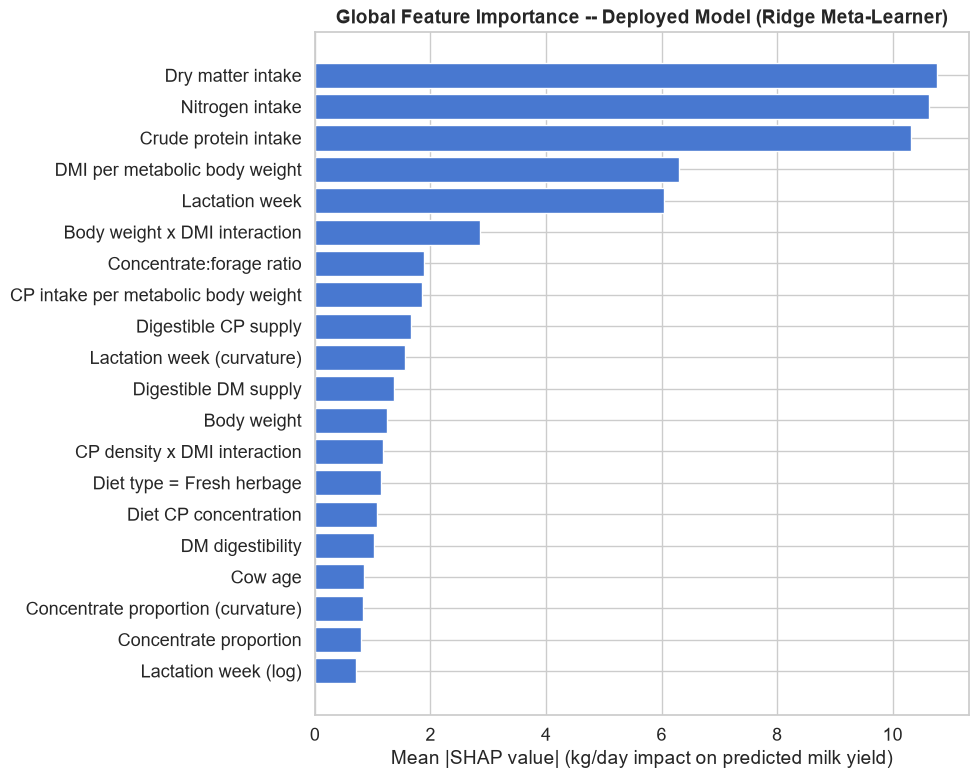

Top 10 drivers of milk yield predictions, on average across the herd:
DMI                  10.777
N_intake             10.627
CP_intake            10.313
DMI_per_metBW         6.299
lactation_week        6.035
BW_x_DMI              2.853
conc_forage_ratio     1.894
CP_per_metBW          1.860
dig_CP                1.660
lact_week_sq          1.562


In [33]:
FEATURE_LABELS = {
    'BW':                 'Body weight',
    'age_months':         'Cow age',
    'lactation_week':     'Lactation week',
    'gestation_week':     'Gestation week',
    'DMI':                'Dry matter intake',
    'CP_intake':          'Crude protein intake',
    'N_intake':           'Nitrogen intake',
    'diet_CP_conc':       'Diet CP concentration',
    'conc_prop':          'Concentrate proportion',
    'forage_prop':        'Forage proportion',
    'DM_digestibility':   'DM digestibility',
    'N_digestibility':    'N digestibility',
    'DMI_per_metBW':      'DMI per metabolic body weight',
    'CP_per_metBW':       'CP intake per metabolic body weight',
    'dig_CP':             'Digestible CP supply',
    'dig_DMI':            'Digestible DM supply',
    'BW_x_DMI':           'Body weight x DMI interaction',
    'CP_density_x_DMI':   'CP density x DMI interaction',
    'conc_forage_ratio':  'Concentrate:forage ratio',
    'lact_week_sq':       'Lactation week (curvature)',
    'age_sq':             'Cow age (curvature)',
    'conc_prop_sq':       'Concentrate proportion (curvature)',
    'ln_lact_week':       'Lactation week (log)',
}

def readable(col):
    if col in FEATURE_LABELS:
        return FEATURE_LABELS[col]
    if col.startswith('diet_'):
        return f"Diet type = {col[5:].replace('_', ' ')}"
    return col


global_importance = final_shap_df.abs().mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20  = global_importance.head(20)
labels = [readable(c) for c in top20.index]
ax.barh(labels[::-1], top20.values[::-1], color=PAL[0], edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (kg/day impact on predicted milk yield)')
ax.set_title('Global Feature Importance -- Deployed Model (Ridge Meta-Learner)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 drivers of milk yield predictions, on average across the herd:")
print(global_importance.head(10).round(3).to_string())

### 10f. Case-by-case explanation

Two entry points:
- `explain_cow(idx)` -- explain a cow already in the training data (by row index).
- `explain_new_cow(raw_input)` -- explain a **fresh farmer-supplied input** (a dict of
  raw, measurable quantities); it re-runs the feature engineering, gets a prediction
  from every base model, and reuses the exact SHAP machinery above.

In [34]:
HERD_MEAN = X.mean()
HERD_AVG_PREDICTION = final_base_value + final_shap_df.mean(axis=0).sum()

def _plain_language(x_row, row_shap, pred, top_n=6):
    contrib = row_shap.sort_values(key=abs, ascending=False)
    lines = [
        f"Predicted milk yield: {pred:.2f} kg/day  (herd average prediction: {HERD_AVG_PREDICTION:.2f} kg/day)",
        "",
        "Main drivers for this cow:",
    ]
    for feat in contrib.index[:top_n]:
        val, mean_, impact = x_row[feat], HERD_MEAN[feat], contrib[feat]
        direction = "increases" if impact > 0 else "decreases"
        rel       = "above" if val > mean_ else "below"
        lines.append(
            f"  - {readable(feat)} = {val:.2f} ({rel} herd average of {mean_:.2f}) "
            f"{direction} predicted yield by {abs(impact):.2f} kg/day"
        )
    return "\n".join(lines)


def _waterfall(row_shap, x_row, base_value, max_display=12):
    exp = shap.Explanation(
        values=row_shap.values,
        base_values=base_value,
        data=x_row.values,
        feature_names=[readable(c) for c in row_shap.index],
    )
    shap.plots.waterfall(exp, max_display=max_display, show=True)


def explain_cow(idx, top_n=6, show_plot=True):
    """Explain a cow already present in the training data (X.loc[idx])."""
    row_shap = final_shap_df.loc[idx]
    x_row    = X.loc[idx]
    pred     = final_base_value + row_shap.sum()

    if show_plot:
        _waterfall(row_shap, x_row, final_base_value)
    print(_plain_language(x_row, row_shap, pred, top_n=top_n))
    return pred, row_shap


def engineer_single(raw):
    """
    Rebuild the full engineered-feature row from raw, farmer-measurable inputs.
    `raw` keys: BW, age_months, lactation_week, gestation_week, DMI, CP_intake,
    N_intake, diet_CP_conc, conc_prop, forage_prop, DM_digestibility,
    N_digestibility, diet_type (must match one of the trained diet categories).
    """
    BW_, AGE_, LW_  = raw['BW'], raw['age_months'], raw['lactation_week']
    GW_             = raw.get('gestation_week', 0.0)
    DMI_, CPI_, NI_ = raw['DMI'], raw['CP_intake'], raw['N_intake']
    CPc_            = raw['diet_CP_conc']
    CONC_, FORG_    = raw['conc_prop'], raw['forage_prop']
    DMDG_, ND_      = raw['DM_digestibility'], raw['N_digestibility']

    row = {
        'BW': BW_, 'age_months': AGE_, 'lactation_week': LW_, 'gestation_week': GW_,
        'DMI': DMI_, 'CP_intake': CPI_, 'N_intake': NI_, 'diet_CP_conc': CPc_,
        'conc_prop': CONC_, 'forage_prop': FORG_,
        'DM_digestibility': DMDG_, 'N_digestibility': ND_,
        'DMI_per_metBW':     DMI_ / (BW_ ** 0.75),
        'CP_per_metBW':      CPI_ / (BW_ ** 0.75),
        'dig_CP':            CPI_ * ND_,
        'dig_DMI':           DMI_ * DMDG_,
        'BW_x_DMI':          BW_ * DMI_,
        'CP_density_x_DMI':  CPc_ * DMI_,
        'conc_forage_ratio': CONC_ / (FORG_ + 1e-6),
        'lact_week_sq':      LW_ ** 2,
        'age_sq':            AGE_ ** 2,
        'conc_prop_sq':      CONC_ ** 2,
        'ln_lact_week':      np.log1p(LW_),
    }
    diet_dummy_cols = [c for c in X.columns if c.startswith('diet_') and c != 'diet_CP_conc']
    target_dummy = f"diet_{raw['diet_type']}"
    if target_dummy not in diet_dummy_cols:
        raise ValueError(
            f"Unknown diet_type '{raw['diet_type']}'. Must be one of: "
            f"{[c[5:] for c in diet_dummy_cols]}"
        )
    for c in diet_dummy_cols:
        row[c] = 1.0 if c == target_dummy else 0.0

    missing = [c for c in X.columns if c not in row]
    if missing:
        raise ValueError(f"Unmapped feature columns, check diet_type spelling: {missing}")

    return pd.Series(row)[X.columns].astype(float)


def explain_new_cow(raw_input, top_n=6, show_plot=True):
    """Explain a brand-new, farmer-supplied cow (not in the training set)."""
    x_new  = engineer_single(raw_input)
    X_row  = x_new.to_frame().T
    xbar   = X.mean(axis=0).values

    # base-model predictions, needed to assemble the meta-learner's input row
    p_ridge = ridge_tuned.predict(X_row)[0]
    p_lasso = lasso_tuned.predict(X_row)[0]
    p_xgb   = xgb_tuned.predict(X_row)[0]
    p_lgb   = lgb_tuned.predict(X_row)[0]

    xstack_row = pd.concat([
        x_new,
        pd.Series({'meta_ridge': p_ridge, 'meta_lasso': p_lasso,
                   'meta_xgb': p_xgb, 'meta_lgb': p_lgb})
    ])[X_stack.columns].to_frame().T
    pred = meta_ridge.predict(xstack_row)[0]

    # SHAP for the original features, single row, same machinery as above
    shap_ridge_row = coef_ridge_raw * (x_new.values - xbar)
    shap_lasso_row = coef_lasso_raw * (x_new.values - xbar)
    shap_xgb_row   = xgb_explainer.shap_values(X_row)[0]
    shap_lgb_row   = lgb_explainer.shap_values(X_row)[0]

    total_row = meta_raw_coef[X.columns].values * (x_new.values - xbar)
    total_row = (total_row
                 + meta_raw_coef['meta_ridge'] * shap_ridge_row
                 + meta_raw_coef['meta_lasso'] * shap_lasso_row
                 + meta_raw_coef['meta_xgb']   * shap_xgb_row
                 + meta_raw_coef['meta_lgb']   * shap_lgb_row)

    row_shap = pd.Series(total_row, index=X.columns)

    if show_plot:
        _waterfall(row_shap, x_new, final_base_value)
    print(_plain_language(x_new, row_shap, pred, top_n=top_n))
    return pred, row_shap

### 10g. Demo

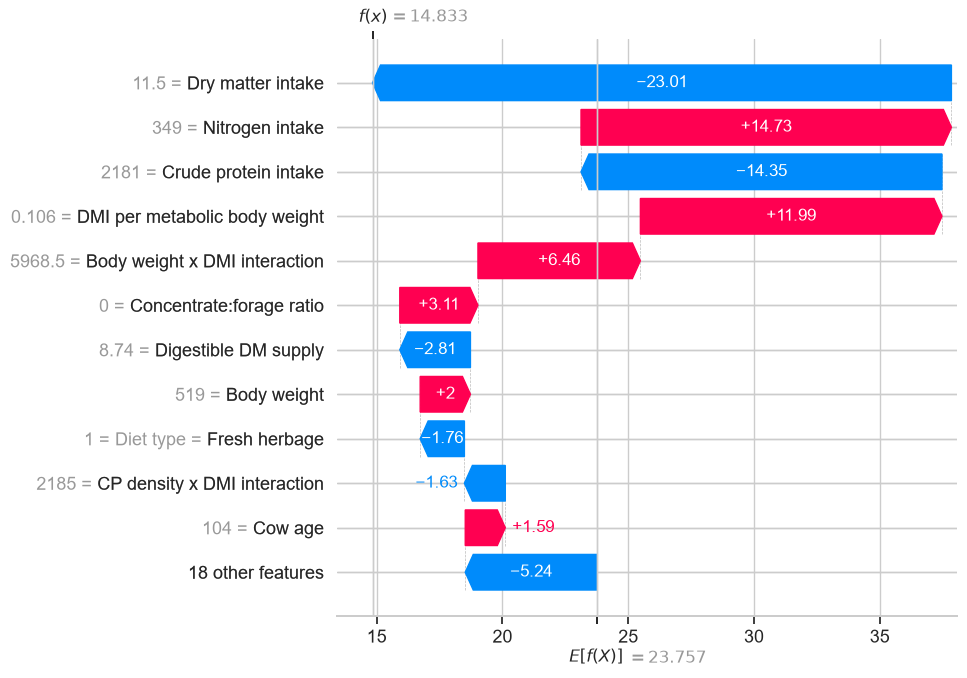

Predicted milk yield: 14.83 kg/day  (herd average prediction: 23.80 kg/day)

Main drivers for this cow:
  - Dry matter intake = 11.50 (below herd average of 18.28) decreases predicted yield by 23.01 kg/day
  - Nitrogen intake = 349.00 (below herd average of 467.23) increases predicted yield by 14.73 kg/day
  - Crude protein intake = 2181.00 (below herd average of 2920.33) decreases predicted yield by 14.35 kg/day
  - DMI per metabolic body weight = 0.11 (below herd average of 0.14) increases predicted yield by 11.99 kg/day
  - Body weight x DMI interaction = 5968.50 (below herd average of 11729.85) increases predicted yield by 6.46 kg/day
  - Concentrate:forage ratio = 0.00 (below herd average of 0.29) increases predicted yield by 3.11 kg/day


In [35]:
# Explain an existing cow from the training data
_ = explain_cow(X.index[0])

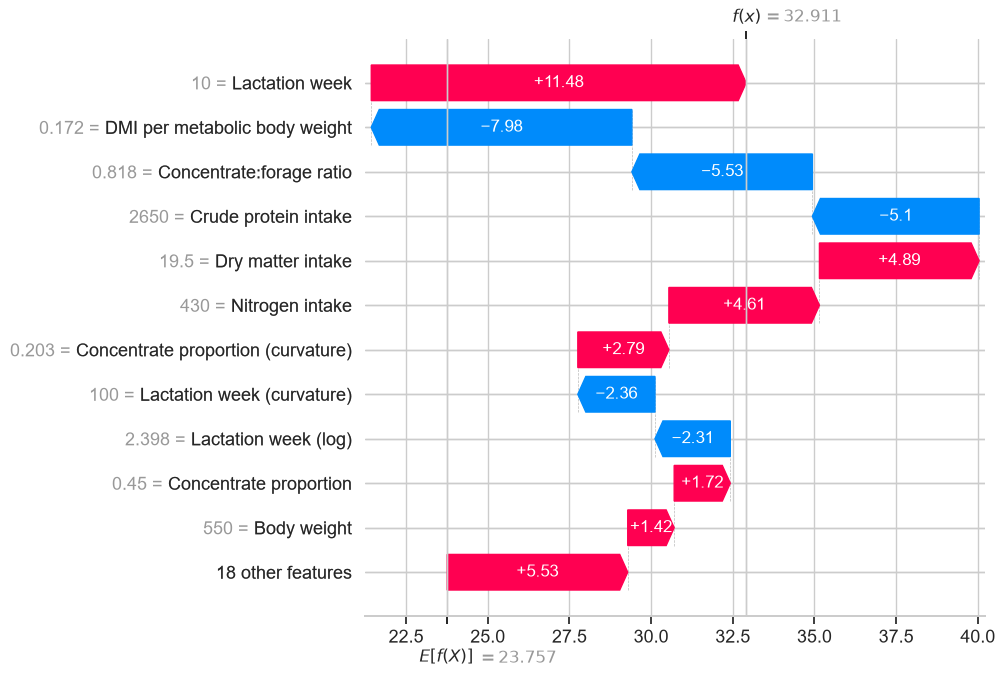

Predicted milk yield: 32.91 kg/day  (herd average prediction: 23.80 kg/day)

Main drivers for this cow:
  - Lactation week = 10.00 (below herd average of 31.87) increases predicted yield by 11.48 kg/day
  - DMI per metabolic body weight = 0.17 (above herd average of 0.14) decreases predicted yield by 7.98 kg/day
  - Concentrate:forage ratio = 0.82 (above herd average of 0.29) decreases predicted yield by 5.53 kg/day
  - Crude protein intake = 2650.00 (below herd average of 2920.33) decreases predicted yield by 5.10 kg/day
  - Dry matter intake = 19.50 (above herd average of 18.28) increases predicted yield by 4.89 kg/day
  - Nitrogen intake = 430.00 (below herd average of 467.23) increases predicted yield by 4.61 kg/day


In [36]:
# Explain a brand-new, farmer-supplied cow
sample_farmer_input = {
    'BW': 550, 'age_months': 42, 'lactation_week': 10, 'gestation_week': 0,
    'DMI': 19.5, 'CP_intake': 2650, 'N_intake': 430, 'diet_CP_conc': 165,
    'conc_prop': 0.45, 'forage_prop': 0.55,
    'DM_digestibility': 0.72, 'N_digestibility': 0.65,
    'diet_type': df['3.-Diet-type'].mode()[0],   # swap in the farmer's actual diet type
}
_ = explain_new_cow(sample_farmer_input)

### Summary & Notes

**What each model adds:**
- **Ridge / Lasso** — fast linear baselines; Lasso does built-in feature selection
- **XGBoost / LightGBM** — capture nonlinear interactions; typically best single models on tabular data  
- **Stacking (Ridge meta)** — uses OOF preds as extra features; meta-learner learns *how much to trust* each base model in different regions of the input space   